<a href="https://colab.research.google.com/github/Optimus0205/Data_Science_Project/blob/main/Feature_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option('display.max_columns',None)

In [ ]:
df=pd.read_csv('/content/gurgaon_properties_missing_value_imputation.csv')

In [ ]:
df.shape

(3268, 18)

In [ ]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,eldeco accolade,sohna road,0.87,5963.0,2,2,3+,10.0,Relatively New,1131.0,1,0,0,0,0,0,72
1,flat,tulip violet,sector 69,2.00,9583.0,4,4,2,0.0,Relatively New,1889.0,0,0,0,0,0,0,157
2,flat,unitech uniworld gardens,sector 47,2.40,11505.0,3,3,3+,10.0,Moderately Old,1888.0,0,1,0,0,0,1,120
3,flat,emaar palm gardens,sector 83,1.75,9211.0,3,3,3,6.0,Relatively New,1600.0,0,1,0,0,0,1,174
4,flat,vatika iris floors,sector 82,0.63,5590.0,2,2,3+,2.0,Relatively New,1026.0,1,0,0,0,0,0,110


In [ ]:
train_df=df.drop(columns=['society','price_per_sqft'])
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sohna road,0.87,2,2,3+,10.0,Relatively New,1131.0,1,0,0,0,0,0,72
1,flat,sector 69,2.00,4,4,2,0.0,Relatively New,1889.0,0,0,0,0,0,0,157
2,flat,sector 47,2.40,3,3,3+,10.0,Moderately Old,1888.0,0,1,0,0,0,1,120
3,flat,sector 83,1.75,3,3,3,6.0,Relatively New,1600.0,0,1,0,0,0,1,174
4,flat,sector 82,0.63,2,2,3+,2.0,Relatively New,1026.0,1,0,0,0,0,0,110


Now working with the columns which have more dependency on price column

### 1. luxury_score

<Axes: xlabel='luxury_score'>

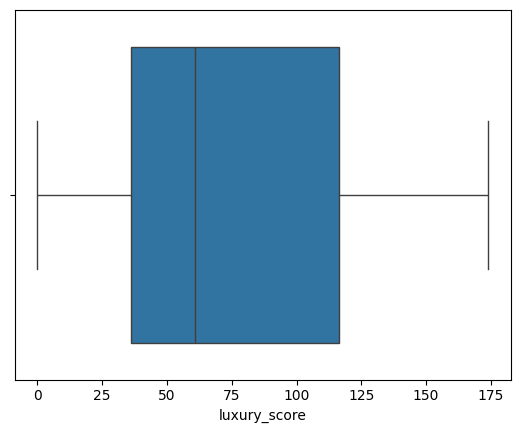

In [ ]:
sns.boxplot(x=df['luxury_score'])

In [ ]:
def categorize_luxury(score):
  if 0<=score<50:
    return 'LOW'
  elif 50<=score<150:
    return 'MODERATE'
  elif 150<=score<=175:
    return 'HIGH'
  else:
    return None    # undefined values

In [ ]:
train_df['luxury_category']=train_df['luxury_score'].apply(categorize_luxury)
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sohna road,0.87,2,2,3+,10.0,Relatively New,1131.0,1,0,0,0,0,0,72,MODERATE
1,flat,sector 69,2.00,4,4,2,0.0,Relatively New,1889.0,0,0,0,0,0,0,157,HIGH
2,flat,sector 47,2.40,3,3,3+,10.0,Moderately Old,1888.0,0,1,0,0,0,1,120,MODERATE
3,flat,sector 83,1.75,3,3,3,6.0,Relatively New,1600.0,0,1,0,0,0,1,174,HIGH
4,flat,sector 82,0.63,2,2,3+,2.0,Relatively New,1026.0,1,0,0,0,0,0,110,MODERATE


### 2. floorNum

<Axes: xlabel='floorNum'>

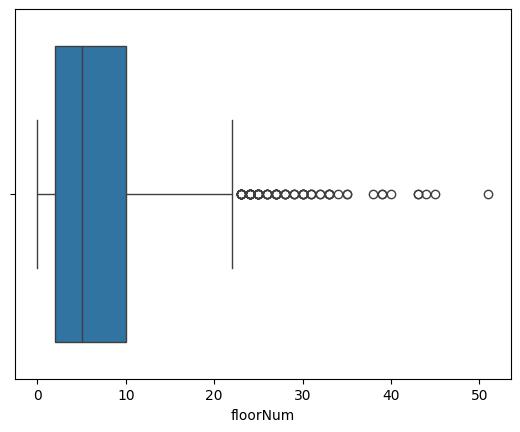

In [ ]:
sns.boxplot(x=df['floorNum'])

In [ ]:
def categorize_floor(floor):
  if 0<=floor<=2:
    return 'Low Floor'
  elif 3<=floor<=10:
    return 'Mid Floor'
  elif 11<=floor<=51:
    return 'High Floor'
  else:
    return None        # Undefined values

In [ ]:
train_df['floor_category']=train_df['floorNum'].apply(categorize_floor)
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sohna road,0.87,2,2,3+,10.0,Relatively New,1131.0,1,0,0,0,0,0,72,MODERATE,Mid Floor
1,flat,sector 69,2.00,4,4,2,0.0,Relatively New,1889.0,0,0,0,0,0,0,157,HIGH,Low Floor
2,flat,sector 47,2.40,3,3,3+,10.0,Moderately Old,1888.0,0,1,0,0,0,1,120,MODERATE,Mid Floor
3,flat,sector 83,1.75,3,3,3,6.0,Relatively New,1600.0,0,1,0,0,0,1,174,HIGH,Mid Floor
4,flat,sector 82,0.63,2,2,3+,2.0,Relatively New,1026.0,1,0,0,0,0,0,110,MODERATE,Low Floor


In [ ]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [ ]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sohna road,0.87,2,2,3+,Relatively New,1131.0,1,0,0,0,0,0,MODERATE,Mid Floor
1,flat,sector 69,2.00,4,4,2,Relatively New,1889.0,0,0,0,0,0,0,HIGH,Low Floor
2,flat,sector 47,2.40,3,3,3+,Moderately Old,1888.0,0,1,0,0,0,1,MODERATE,Mid Floor
3,flat,sector 83,1.75,3,3,3,Relatively New,1600.0,0,1,0,0,0,1,HIGH,Mid Floor
4,flat,sector 82,0.63,2,2,3+,Relatively New,1026.0,1,0,0,0,0,0,MODERATE,Low Floor


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'sector 1',
       'sector 102', 'sector 103', 'sector 104', 'sector 105',
       'sector 106', 'sector 107', 'sector 108', 'sector 109',
       'sector 10a', 'sector 11', 'sector 110', 'sector 111',
       'sector 112', 'sector 113', 'sector 12', 'sector 13', 'sector 14',
       'sector 15', 'sector 17', 'sector 17a', 'sector 17b', 'sector 2',
       'sector 21', 'sector 22', 'sector 23', 'sector 24', 'sector 25',
       'sector 26', 'sector 27', 'sector 28', 'sector 3',
       'sector 3 phase 2', 'sector 3 phase 3 extension', 'sector 30',
       'sector 31', 'sector 33', 'sector 36', 'sector 36a', 'sector 37',
       'sector 37c', 'sector 37d', 'sector 38', 'sector 39', 'sector 4',
       'sector 40', 'sector 41', 'sector 43', 'sector 45', 'sector 46',
       'sector 47', 'sector 48', 'sector 49', 'sector 5', 'sector 50',
       'sector 51', 'sector 52', 'sector 53', 'sector 54', 'sector 5

In [ ]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,111.0,2,2,4.0,3.0,1131.0,1,0,0,0,0,0,2.0,2.0
1,0.0,78.0,4,4,2.0,3.0,1889.0,0,0,0,0,0,0,0.0,1.0
2,0.0,53.0,3,3,4.0,0.0,1888.0,0,1,0,0,0,1,2.0,2.0
3,0.0,95.0,3,3,3.0,3.0,1600.0,0,1,0,0,0,1,0.0,2.0
4,0.0,93.0,2,2,4.0,3.0,1026.0,1,0,0,0,0,0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3263,0.0,6.0,3,4,4.0,3.0,2359.0,0,1,0,0,0,1,0.0,2.0
3264,0.0,82.0,2,2,1.0,0.0,639.0,0,0,0,0,0,0,2.0,2.0
3265,0.0,4.0,3,3,3.0,3.0,2200.0,1,1,0,0,0,0,1.0,0.0
3266,0.0,105.0,3,4,3.0,3.0,1805.0,0,1,0,0,0,0,1.0,2.0


In [ ]:
y_label

,price
0,0.87
1,2.00
2,2.40
3,1.75
4,0.63
...,...
3263,2.23
3264,0.59
3265,2.61
3266,1.55


# Feature Selection Techniques

## 1. Technique 1 - Correlation analysis

<Axes: >

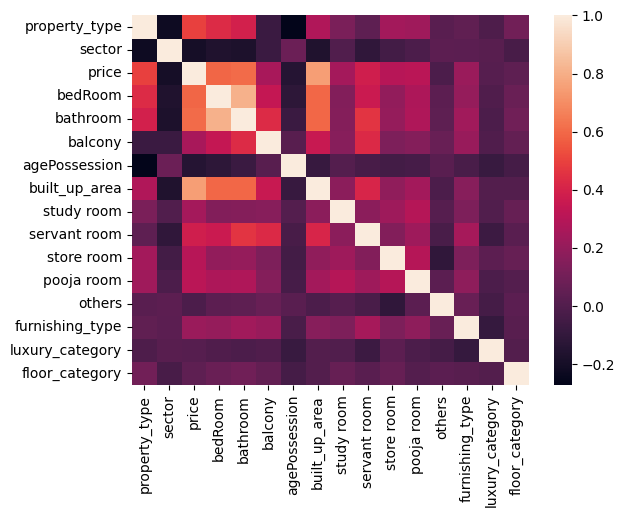

In [ ]:
sns.heatmap(data_label_encoded.corr())

In [ ]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.198214
1,price,1.000000
2,bedRoom,0.588053
3,bathroom,0.603987
4,balcony,0.259616
5,agePossession,-0.145427
6,built_up_area,0.746839
7,study room,0.247109
8,servant room,0.383321
9,store room,0.301670


##2. Technique 2 - Random Forest Feature Importance

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.651661
1,sector,0.105791
0,property_type,0.097663
2,bedRoom,0.026342
3,bathroom,0.023530
8,servant room,0.019142
5,agePossession,0.014782
4,balcony,0.011520
7,study room,0.010473
12,furnishing_type,0.009878


## 3. Technique 3 - Gradient Boosting Feature importances

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.681948
1,sector,0.101617
0,property_type,0.094768
2,bedRoom,0.042416
3,bathroom,0.030580
8,servant room,0.027167
9,store room,0.007668
5,agePossession,0.004442
7,study room,0.003501
12,furnishing_type,0.003133


## 4. Technique 4 - Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.814632
0,property_type,0.195155
1,sector,0.143080
8,servant room,0.009263
4,balcony,0.003712
7,study room,0.003118
9,store room,0.001435
14,floor_category,0.001435
3,bathroom,0.001432
11,others,0.000084


## 5. Technique 5 - LASSO
using linear model in ordinal encoding and doesn't give good results

sector value is at last

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.551054
0,property_type,0.727750
3,bathroom,0.278246
9,store room,0.207606
7,study room,0.179702
8,servant room,0.171324
12,furnishing_type,0.164915
10,pooja room,0.078080
13,luxury_category,0.061636
2,bedRoom,0.033145


## 6. Technique 6 - RFE
Recursive Feature Elimination

Features are eliminated and iterate this process to the number of features

In [ ]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6

,feature,rfe_score
6,built_up_area,0.649010
1,sector,0.105908
0,property_type,0.100159
2,bedRoom,0.025821
3,bathroom,0.024610
8,servant room,0.018672
5,agePossession,0.015053
4,balcony,0.011828
12,furnishing_type,0.009794
9,store room,0.008885


## 7. Technique 7 - Linear Regression Weights

In [28]:
from sklearn.linear_model import LinearRegression

# Train a linear regression model on the label-encoded and standardized training data
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7

,feature,reg_coeffs
6,built_up_area,1.553434
0,property_type,0.725188
3,bathroom,0.285821
9,store room,0.212162
7,study room,0.187891
8,servant room,0.180182
12,furnishing_type,0.174491
10,pooja room,0.081378
13,luxury_category,0.072322
2,bedRoom,0.035244


## 8. Technique 8 - SHAP

In [29]:
!pip install shap

In [30]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)

shap_values

array([[-0.2077177 , -0.45466236, -0.04145702, ..., -0.01604714,
         0.00555632, -0.0098838 ],
       [-0.28497085,  0.05287164,  0.02586293, ..., -0.02476986,
         0.03986055,  0.00125241],
       [-0.39889189,  0.36987641, -0.03310816, ...,  0.00178366,
        -0.01183197, -0.04298813],
       ...,
       [-0.51294444, -0.04331295, -0.03043775, ..., -0.03472928,
         0.01273395,  0.07925741],
       [-0.40209313, -0.57354959, -0.01146085, ..., -0.03284982,
         0.00732772, -0.01308389],
       [-0.37721895, -0.31798738,  0.01545969, ..., -0.03077931,
         0.03865468, -0.01227236]])

In [31]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
6,built_up_area,1.306261
0,property_type,0.507326
1,sector,0.380367
3,bathroom,0.102395
8,servant room,0.100555
2,bedRoom,0.058466
4,balcony,0.039061
12,furnishing_type,0.031454
14,floor_category,0.028006
5,agePossession,0.026073


Now merging the values from all the feature  selection technique

In [32]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [33]:
final_fi_df

,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
sector,-0.198214,0.105791,0.101617,0.143080,-0.059570,0.105908,-0.068628,0.380367
bedRoom,0.588053,0.026342,0.042416,-0.012111,0.033145,0.025821,0.035244,0.058466
bathroom,0.603987,0.023530,0.030580,0.001432,0.278246,0.024610,0.285821,0.102395
balcony,0.259616,0.011520,0.001361,0.003712,-0.045400,0.011828,-0.068059,0.039061
agePossession,-0.145427,0.014782,0.004442,-0.006244,-0.017283,0.015053,-0.024428,0.026073
built_up_area,0.746839,0.651661,0.681948,0.814632,1.551054,0.649010,1.553434,1.306261
study room,0.247109,0.010473,0.003501,0.003118,0.179702,0.007265,0.187891,0.021870
servant room,0.383321,0.019142,0.027167,0.009263,0.171324,0.018672,0.180182,0.100555
store room,0.301670,0.007393,0.007668,0.001435,0.207606,0.008885,0.212162,0.016684


In [34]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [35]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

,0
feature,
built_up_area,0.738037
sector,0.135941
bathroom,0.027280
servant room,0.025765
bedRoom,0.023755
balcony,0.009925
agePossession,0.008672
study room,0.007422
store room,0.007172


In [36]:
# to drop pooja room, study room, others
# but can't drop with a valid proof
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,111.0,2,2,4.0,3.0,1131.0,1,0,0,0,0,0,2.0,2.0
1,0.0,78.0,4,4,2.0,3.0,1889.0,0,0,0,0,0,0,0.0,1.0
2,0.0,53.0,3,3,4.0,0.0,1888.0,0,1,0,0,0,1,2.0,2.0
3,0.0,95.0,3,3,3.0,3.0,1600.0,0,1,0,0,0,1,0.0,2.0
4,0.0,93.0,2,2,4.0,3.0,1026.0,1,0,0,0,0,0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3263,0.0,6.0,3,4,4.0,3.0,2359.0,0,1,0,0,0,1,0.0,2.0
3264,0.0,82.0,2,2,1.0,0.0,639.0,0,0,0,0,0,0,2.0,2.0
3265,0.0,4.0,3,3,3.0,3.0,2200.0,1,1,0,0,0,0,1.0,0.0
3266,0.0,105.0,3,4,3.0,3.0,1805.0,0,1,0,0,0,0,1.0,2.0


In [37]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [38]:
scores.mean()

np.float64(0.8002977487770908)

In [39]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [40]:
scores.mean()

np.float64(0.8002985669372908)

In [41]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [42]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [43]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servant room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,111.0,2,2,4.0,3.0,1131.0,0,0,0,2.0,2.0,0.87
1,0.0,78.0,4,4,2.0,3.0,1889.0,0,0,0,0.0,1.0,2.00
2,0.0,53.0,3,3,4.0,0.0,1888.0,1,0,1,2.0,2.0,2.40
3,0.0,95.0,3,3,3.0,3.0,1600.0,1,0,1,0.0,2.0,1.75
4,0.0,93.0,2,2,4.0,3.0,1026.0,0,0,0,2.0,1.0,0.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3263,0.0,6.0,3,4,4.0,3.0,2359.0,1,0,1,0.0,2.0,2.23
3264,0.0,82.0,2,2,1.0,0.0,639.0,0,0,0,2.0,2.0,0.59
3265,0.0,4.0,3,3,3.0,3.0,2200.0,1,0,0,1.0,0.0,2.61
3266,0.0,105.0,3,4,3.0,3.0,1805.0,1,0,0,1.0,2.0,1.55
